# Del conteo al espectro: unfolding de neutrones

Actividad práctica de 60 minutos para reconstruir el espectro de **un evento real**. El cálculo oficial sigue en C++/ROOT (`macros/deconv_CRNS.C`); Python permite seleccionar el evento, inspeccionar los datos, ejecutar ROOT y visualizar los resultados.

$$
\text{conteos}\rightarrow\text{tasas}\rightarrow R_{ij}\rightarrow
\text{semilla}\rightarrow\text{EM}\rightarrow\text{parada}\rightarrow
\text{refolding}\rightarrow\text{MC}\rightarrow\text{incertidumbre}
$$

| Minutos | Actividad | Pregunta central |
|---:|---|---|
| 0–5 | Conexión con el laboratorio | ¿Qué representa cada canal? |
| 5–20 | Datos, respuestas y modelo directo | ¿Qué predice la semilla? |
| 20–30 | Una iteración explícita | ¿Cómo corrige EM el espectro? |
| 30–48 | EM oficial, parada y refolding | ¿La solución reproduce los datos? |
| 48–55 | Monte Carlo reducido | ¿Cómo se propaga la fluctuación de los conteos? |
| 55–60 | Flujos integrales y cierre | ¿Qué magnitudes físicas obtenemos? |


## 1. Conexión con el laboratorio

Cada canal emplea el mismo tipo de detector central, pero una configuración moderadora distinta. Los moderadores cambian la energía de los neutrones antes de que alcancen el detector; por eso cada canal posee una función respuesta amplia y diferente. Ningún canal mide por sí solo un intervalo energético estrecho: el espectro se infiere usando simultáneamente todas las tasas.

**Pregunta inicial:** si el detector central es el mismo, ¿por qué cambian las tasas entre canales?

<details>
<summary>Respuesta esperada</summary>

Porque cada moderador transforma de manera diferente el campo de neutrones y produce una función respuesta distinta.
</details>


## 2. Preparar la interfaz y seleccionar un evento


In [1]:
import importlib
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

import classroom.python.unfolding_helpers as unfolding_helpers
importlib.reload(unfolding_helpers)  # Evita usar una versión anterior en memoria.

from classroom.python.unfolding_helpers import (
    REPO_DIR,
    em_iteration_history,
    expected_em_log,
    expected_em_output,
    expected_mc_output,
    expected_mc_stats,
    forward_fold,
    load_event_channels,
    load_response_matrix,
    load_seed_spectrum,
    load_shell_config,
    mc_run_summary,
    quantile_summary,
    root_keys,
    run_em,
    run_em_mc,
    scalar_tree_table,
    scientific_inputs,
    tree_branches,
    tree_entry_count,
    tree_names,
    vector_tree_array,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
print("Repositorio:", REPO_DIR)


Repositorio: /workspace


In [2]:
# Esta es la única celda que el estudiante necesita modificar.
CONFIG_FILE = Path("configs/unfolding_configs/config_EM_MC_stop_LCO_15min_ISO.sh")
EVENT_ID = 2
SEED_NUMBER = 1              # 1 = primera semilla PARMA del día seleccionado
REUSE_EXISTING_RESULTS = True

config = load_shell_config(CONFIG_FILE)
main_keys = [
    "CAMPAIGN", "TIME_GRID", "NDET", "STEPS", "MAX_STEPS",
    "BIN_SEED", "CUT", "PHYLST", "SCF", "NEUFTY",
]
selection = pd.DataFrame({
    "variable": ["EVENT_ID", "SEED_NUMBER", *main_keys],
    "valor": [EVENT_ID, SEED_NUMBER, *[config[key] for key in main_keys]],
})
display(selection)


,variable,valor
0,EVENT_ID,2
1,SEED_NUMBER,1
2,CAMPAIGN,LCO
3,TIME_GRID,15
4,NDET,11
5,STEPS,0
6,MAX_STEPS,100
7,BIN_SEED,1
8,CUT,cut1
9,PHYLST,FTFP_BERT


In [3]:
inputs = scientific_inputs(CONFIG_FILE)
input_table = pd.DataFrame([
    {
        "entrada": name,
        "ruta dentro del repositorio": str(path.relative_to(REPO_DIR)),
        "disponible": path.is_file() if name != "respuestas" else path.is_dir(),
    }
    for name, path in inputs.items()
])
display(input_table)
assert input_table["disponible"].all(), "Falta al menos un input científico."


,entrada,ruta dentro del repositorio,disponible
0,conteos,data/external/CRNS_Data/LCO/LCO_data_15min_com...,True
1,semillas,data/external/EXPACS_Data/parma_cpp_flopez/LCO...,True
2,bineado,data/external/EXPACS_Data/parma_cpp_flopez/ICR...,True
3,respuestas,data/external/Response_Functions_CEFNEN_Spectr...,True


## 3. Conteos y tasas por canal

Para un tiempo vivo $T_i$, el código usa:

$$
r_i=\frac{N_i}{T_i},\qquad
\sigma_{N_i}\simeq\sqrt{N_i},\qquad
\sigma_{r_i}\simeq\frac{\sqrt{N_i}}{T_i}.
$$

La tabla contiene solamente los canales activados por `Detectors_Array(...)` en el C++.


,Canal,Configuración,Conteos,Tiempo vivo [s],Tasa [s⁻¹],Incertidumbre [s⁻¹],Incertidumbre relativa [%]
0,D01,12 cm HDPE,573,900.000000,0.63667,0.02660,4.2
1,D02,10 cm HDPE,607,900.000000,0.67444,0.02737,4.1
2,D03,4 cm HDPE,243,900.000000,0.27000,0.01732,6.4
3,D04,Cilindro HDPE,494,900.000000,0.54889,0.02470,4.5
4,D05,7 mm Al + núcleo BHDPE,41,900.000000,0.04556,0.00711,15.6
5,D09,20 cm BHDPE + 1″,10,900.000000,0.01111,0.00351,31.6
6,D10,Cilindro 4 cm,533,900.000000,0.59222,0.02565,4.3
7,D11,Cilindro 3 cm,367,900.000000,0.40778,0.02129,5.2
8,D12,Pb + núcleo BHDPE 10 cm,57,900.000000,0.06333,0.00839,13.2
9,D13,1″ BHDPE + grafito 15 cm,49,900.000000,0.05444,0.00778,14.3


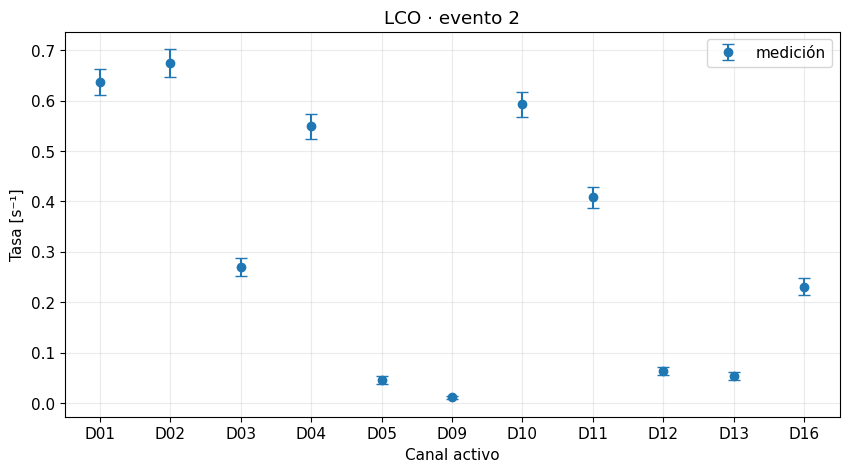

In [4]:
event_table = load_event_channels(CONFIG_FILE, EVENT_ID)
display(event_table.style.format({
    "Tasa [s⁻¹]": "{:.5f}",
    "Incertidumbre [s⁻¹]": "{:.5f}",
    "Incertidumbre relativa [%]": "{:.1f}",
}))

channels = event_table["Canal"].to_numpy()
measured_rate = event_table["Tasa [s⁻¹]"].to_numpy()
measured_sigma = event_table["Incertidumbre [s⁻¹]"].to_numpy()

fig, axis = plt.subplots()
axis.errorbar(
    channels, measured_rate, yerr=measured_sigma,
    fmt="o", capsize=4, color="tab:blue", label="medición",
)
axis.set(xlabel="Canal activo", ylabel="Tasa [s⁻¹]",
         title=f"{config['CAMPAIGN']} · evento {EVENT_ID}")
axis.legend()
plt.show()


**Preguntas para discutir**

1. ¿Qué canal presenta la mayor tasa?
2. ¿Qué canal tiene la mayor incertidumbre relativa?
3. ¿Por qué un canal con pocos conteos aporta menos información estadística?


## 4. Funciones respuesta

\(R_{ij}\) representa la sensibilidad del canal \(i\) al bin energético \(j\). Primero compararemos un moderador delgado, una configuración con Pb y el detector desnudo; luego veremos todos los canales activos.


In [5]:
response_matrix, energy_bins, response_metadata = load_response_matrix(CONFIG_FILE)
energy_mid = energy_bins["Emid"].to_numpy()
energy_width = energy_bins["Ewid"].to_numpy()
energy_edges = np.r_[energy_bins["Elower"].to_numpy(),
                     energy_bins["Eupper"].iloc[-1]]

print("Forma de R:", response_matrix.shape)
display(response_metadata[["Canal", "Configuración", "Archivo"]])


Forma de R: (11, 129)


,Canal,Configuración,Archivo
0,D01,12 cm HDPE,Efi_1_12cmHDPE_FTFP_BERT_VV_smooth_smooth_root...
1,D02,10 cm HDPE,Efi_2_10cmHDPE_FTFP_BERT_VV_smooth_smooth_root...
2,D03,4 cm HDPE,Efi_3_4cmHDPE_FTFP_BERT_VV_smooth_smooth_root_...
3,D04,Cilindro HDPE,Efi_4_CylinderHDPE_FTFP_BERT_VV_smooth_smooth_...
4,D05,7 mm Al + núcleo BHDPE,Efi_5_Cylinder7mmAl_1.8cmBHDPECore_FTFP_BERT_V...
5,D09,20 cm BHDPE + 1″,Efi_9_20cmBHDPE_1.0inch_FTFP_BERT_VV_smooth_sm...
6,D10,Cilindro 4 cm,Efi_10_Cylinder_4cm_FTFP_BERT_VV_smooth_smooth...
7,D11,Cilindro 3 cm,Efi_11_Cylinder_3cm_FTFP_BERT_VV_smooth_smooth...
8,D12,Pb + núcleo BHDPE 10 cm,Efi_12_Pb_10cmBHDPEcore_FTFP_BERT_VV_smooth_sm...
9,D13,1″ BHDPE + grafito 15 cm,Efi_13_1inchBHDPE_15cmGraphite_FTFP_BERT_VV_sm...


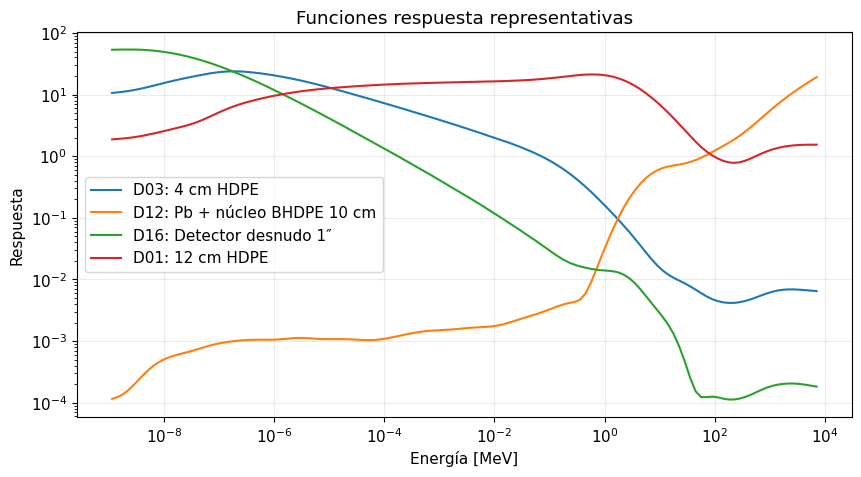

In [6]:
representative_channels = ["D03", "D12", "D16","D01"]
fig, axis = plt.subplots()
for channel in representative_channels:
    row = response_metadata.index[response_metadata["Canal"] == channel][0]
    label = response_metadata.loc[row, "Configuración"]
    axis.loglog(energy_mid, response_matrix[row], label=f"{channel}: {label}")
axis.set(xlabel="Energía [MeV]", ylabel="Respuesta",
         title="Funciones respuesta representativas")
axis.legend()
plt.show()


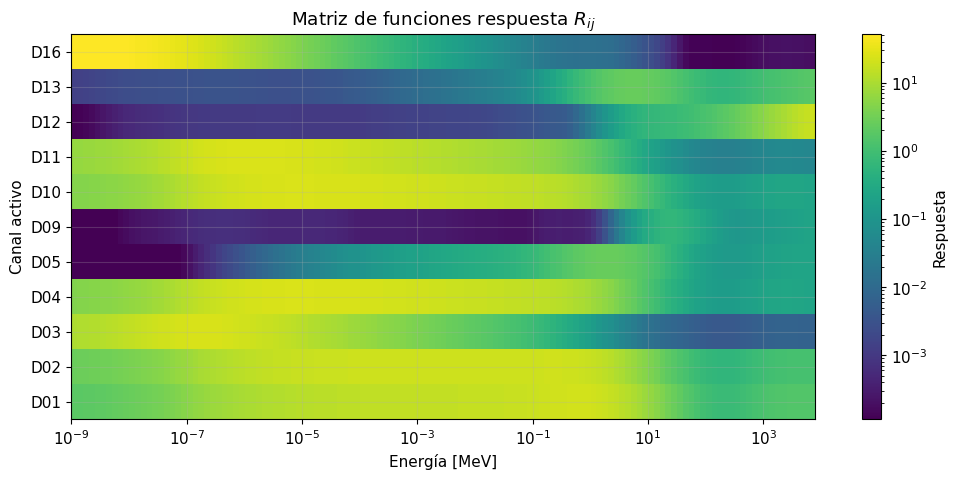

In [7]:
positive = response_matrix[response_matrix > 1e-22]
color_norm = LogNorm(
    vmin=np.quantile(positive, 0.02),
    vmax=np.quantile(positive, 0.995),
)
fig, axis = plt.subplots(figsize=(12, 5))
mesh = axis.pcolormesh(
    energy_edges,
    np.arange(len(channels) + 1),
    response_matrix,
    shading="flat",
    norm=color_norm,
    cmap="viridis",
)
axis.set_xscale("log")
axis.set(
    xlabel="Energía [MeV]",
    ylabel="Canal activo",
    title="Matriz de funciones respuesta $R_{ij}$",
    yticks=np.arange(len(channels)) + 0.5,
    yticklabels=channels,
)
fig.colorbar(mesh, ax=axis, label="Respuesta")
plt.show()


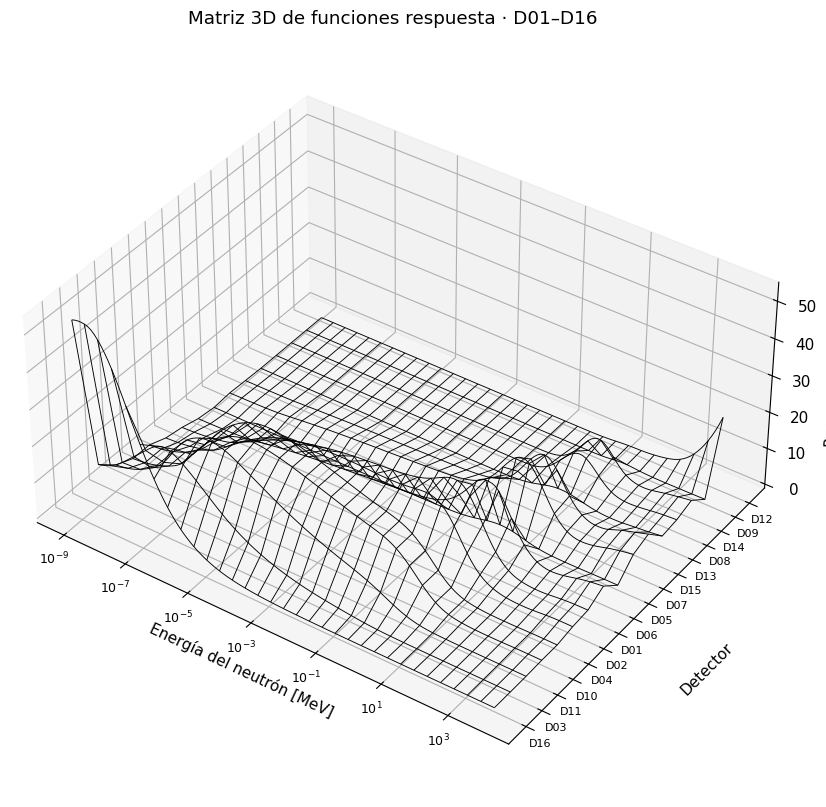

In [8]:
# Matriz completa D01–D16 solo para esta comparación visual.
# El orden reproduce la lectura por columnas de la leyenda de referencia.
detector_order_3d = [
    "D16", "D03", "D11", "D10", "D04", "D02", "D01", "D06",
    "D05", "D07", "D15", "D13", "D08", "D14", "D09", "D12",
]

response_matrix_16, _, response_metadata_16 = load_response_matrix(
    CONFIG_FILE, include_inactive=True,
)
row_by_channel = {
    channel: row
    for row, channel in enumerate(response_metadata_16["Canal"])
}
response_3d = response_matrix_16[
    [row_by_channel[channel] for channel in detector_order_3d]
]

log_energy = np.log10(energy_mid)
detector_position = np.arange(len(detector_order_3d))
energy_grid, detector_grid = np.meshgrid(log_energy, detector_position)

fig = plt.figure(figsize=(15, 9))
axis = fig.add_subplot(111, projection="3d")
axis.plot_wireframe(
    energy_grid,
    detector_grid,
    response_3d,
    rstride=1,
    cstride=4,
    color="black",
    linewidth=0.65,
)

energy_exponents = np.arange(-9, 5, 2)
energy_exponents = energy_exponents[
    (energy_exponents >= np.floor(log_energy.min()))
    & (energy_exponents <= np.ceil(log_energy.max()))
]
axis.set_xticks(energy_exponents)
axis.set_xticklabels([
    rf"$10^{{{exponent}}}$" for exponent in energy_exponents
])
axis.set_yticks(detector_position)
axis.set_yticklabels(detector_order_3d)
axis.set(
    xlabel="Energía del neutrón [MeV]",
    ylabel="Detector",
    zlabel=r"Respuesta [cm$^2$]",
    title="Matriz 3D de funciones respuesta · D01–D16",
)
axis.tick_params(axis="x", labelsize=9, pad=2)
axis.tick_params(axis="y", labelsize=8, pad=0)
axis.yaxis.labelpad = 18
axis.view_init(elev=38, azim=-55)
axis.set_box_aspect((2.2, 1.8, 1.0))
fig.subplots_adjust(left=0.02, right=0.92, bottom=0.05, top=0.90)
plt.show()


**Preguntas para discutir**

- ¿Qué canales mantienen sensibilidad a energías más altas?
- ¿En qué zonas las respuestas se parecen demasiado?
- Si varias filas de \(R\) son muy similares, ¿qué parte del espectro estará peor restringida?


## 5. Modelo directo: forward folding

Antes del problema inverso, evaluamos una predicción:

$
\widehat n_i=\sum_j R_{ij}\,\phi_j\,\Delta E_j.
$

Conocidos $\phi$ y $R$, calcular tasas es directo. El unfolding intenta lo contrario: estimar $\phi$ a partir de pocas tasas y respuestas amplias. Como hay menos canales que bins energéticos, diferentes espectros pueden producir tasas parecidas.


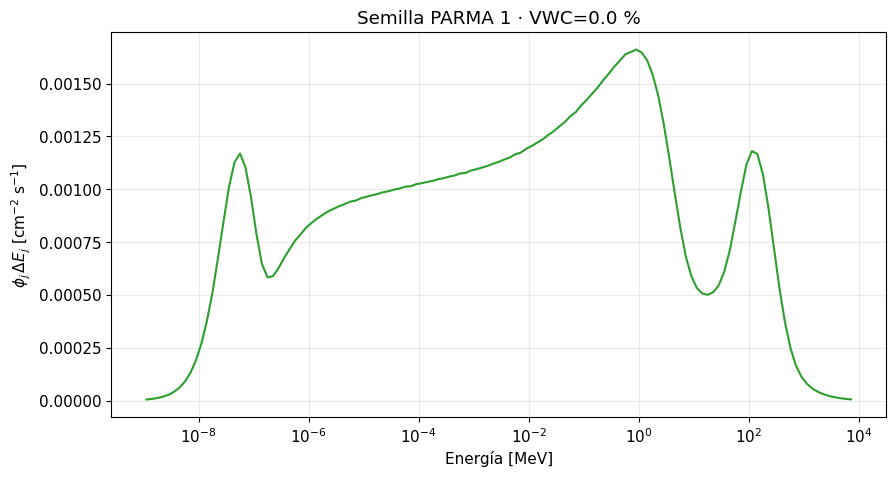

In [9]:
seed_spectrum, water_fraction = load_seed_spectrum(CONFIG_FILE, SEED_NUMBER)
seed_flux = seed_spectrum["Flujo diferencial"].to_numpy()
seed_integral = seed_spectrum["Flujo por bin"].to_numpy()

fig, axis = plt.subplots()
#axis.loglog(energy_mid, seed_integral, color="tab:green")
axis.semilogx(
    energy_mid,
    seed_integral,
    color="tab:green",
)
axis.set(
    xlabel="Energía [MeV]",
    ylabel=r"$\phi_j\,\Delta E_j$ [cm$^{-2}$ s$^{-1}$]",
    title=f"Semilla PARMA {SEED_NUMBER} · VWC={100*water_fraction:.1f} %",
)
plt.show()


,Canal,Configuración,Tasa [s⁻¹],Incertidumbre [s⁻¹],Predicción semilla [s⁻¹],Predicción / medición
0,D01,12 cm HDPE,0.63667,0.02660,1.41191,2.218
1,D02,10 cm HDPE,0.67444,0.02737,1.57773,2.339
2,D03,4 cm HDPE,0.27000,0.01732,0.69379,2.570
3,D04,Cilindro HDPE,0.54889,0.02470,1.55852,2.839
4,D05,7 mm Al + núcleo BHDPE,0.04556,0.00711,0.06703,1.471
5,D09,20 cm BHDPE + 1″,0.01111,0.00351,0.00476,0.428
6,D10,Cilindro 4 cm,0.59222,0.02565,1.55578,2.627
7,D11,Cilindro 3 cm,0.40778,0.02129,1.18718,2.911
8,D12,Pb + núcleo BHDPE 10 cm,0.06333,0.00839,0.02423,0.383
9,D13,1″ BHDPE + grafito 15 cm,0.05444,0.00778,0.04620,0.849


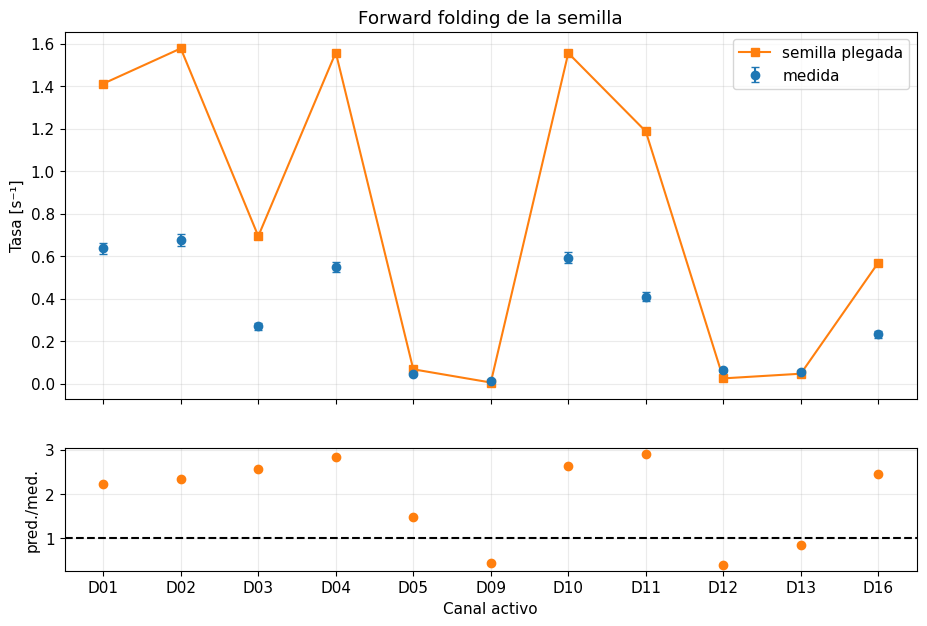

In [10]:
seed_prediction = forward_fold(response_matrix, seed_flux, energy_width)
seed_ratio = np.divide(
    seed_prediction, measured_rate,
    out=np.full_like(seed_prediction, np.nan),
    where=measured_rate > 0,
)
forward_table = event_table[["Canal", "Configuración", "Tasa [s⁻¹]",
                             "Incertidumbre [s⁻¹]"]].copy()
forward_table["Predicción semilla [s⁻¹]"] = seed_prediction
forward_table["Predicción / medición"] = seed_ratio
display(forward_table.style.format({
    "Tasa [s⁻¹]": "{:.5f}",
    "Incertidumbre [s⁻¹]": "{:.5f}",
    "Predicción semilla [s⁻¹]": "{:.5f}",
    "Predicción / medición": "{:.3f}",
}))

x = np.arange(len(channels))
fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)
top.errorbar(x, measured_rate, yerr=measured_sigma, fmt="o",
             capsize=3, label="medida")
top.plot(x, seed_prediction, "s-", label="semilla plegada")
top.set(ylabel="Tasa [s⁻¹]", title="Forward folding de la semilla")
top.legend()
bottom.axhline(1.0, color="black", linestyle="--")
bottom.plot(x, seed_ratio, "o", color="tab:orange")
bottom.set(
    ylabel="pred./med.",
    xlabel="Canal activo",
    xticks=x,
    xticklabels=channels,
)
plt.show()


Un cociente mayor que uno indica que la semilla sobreestima el canal; uno menor que uno indica que lo subestima. ¿Qué canales exigen la mayor corrección?


## 6. Una iteración explícita de EM

Esta única iteración en Python es **didáctica**; no sustituye al C++ oficial.

$$
\phi_j^{(s+1)}
=
\phi_j^{(s)}
\frac{\sum_iR_{ij}\left(n_i/\widehat n_i^{(s)}\right)}
     {\sum_iR_{ij}}.
$$

Pasos: (1) espectro actual, (2) plegamiento, (3) cocientes por canal, (4) retroproyección, (5) nuevo espectro y (6) nuevo plegamiento.


In [11]:
# 1–2. Espectro actual y plegamiento
phi_before = seed_flux.copy()
predicted_before = forward_fold(response_matrix, phi_before, energy_width)

# 3. Factores de corrección por canal
channel_correction = measured_rate / predicted_before

# 4–5. Retroproyección y nuevo espectro
back_projection = (
    response_matrix.T @ channel_correction
) / response_matrix.sum(axis=0)
phi_after = phi_before * back_projection

# 6. Nuevo plegamiento y diagnósticos
predicted_after = forward_fold(response_matrix, phi_after, energy_width)
chi2_before = np.sum(((measured_rate - predicted_before) / measured_sigma) ** 2)
chi2_after = np.sum(((measured_rate - predicted_after) / measured_sigma) ** 2)
diff_after = (
    np.abs(phi_after * energy_width - phi_before * energy_width).sum()
    / (phi_before * energy_width).sum()
)

display(pd.DataFrame({
    "Canal": channels,
    "medida / predicción inicial": channel_correction,
}).style.format({"medida / predicción inicial": "{:.3f}"}))
print(f"χ² antes  = {chi2_before:.3f}")
print(f"χ² después= {chi2_after:.3f}")
print(f"diff       = {diff_after:.5f}")


,Canal,medida / predicción inicial
0,D01,0.451
1,D02,0.427
2,D03,0.389
3,D04,0.352
4,D05,0.680
5,D09,2.336
6,D10,0.381
7,D11,0.343
8,D12,2.614
9,D13,1.178


χ² antes  = 7440.171
χ² después= 49.794
diff       = 0.56001


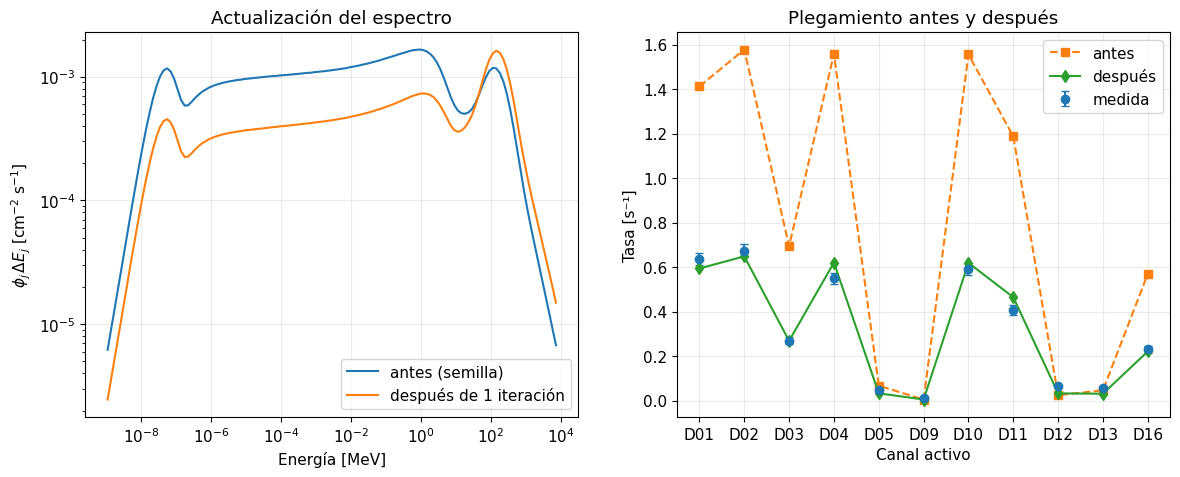

In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))
left.loglog(energy_mid, phi_before * energy_width,
            label="antes (semilla)")
left.loglog(energy_mid, phi_after * energy_width,
            label="después de 1 iteración")
left.set(xlabel="Energía [MeV]",
         ylabel=r"$\phi_j\,\Delta E_j$ [cm$^{-2}$ s$^{-1}$]",
         title="Actualización del espectro")
left.legend()

x = np.arange(len(channels))
right.errorbar(x, measured_rate, yerr=measured_sigma, fmt="o",
               capsize=3, label="medida")
right.plot(x, predicted_before, "s--", label="antes")
right.plot(x, predicted_after, "d-", label="después")
right.set(xlabel="Canal activo", ylabel="Tasa [s⁻¹]",
          title="Plegamiento antes y después",
          xticks=x, xticklabels=channels)
right.legend()
plt.show()


## 7. Ejecutar el EM nominal con C++/ROOT

Flujo real de ejecución:

```text
Notebook Python → helper Python → script Bash local
→ macros/deconv_CRNS.C → archivo ROOT
```

Se procesa un solo `EVENT_ID`, sin SLURM. Si el ROOT ya existe y `REUSE_EXISTING_RESULTS=True`, se reutiliza para que repetir el notebook sea rápido.


In [13]:
em_file = expected_em_output(CONFIG_FILE, EVENT_ID)
em_log = expected_em_log(CONFIG_FILE, EVENT_ID)
command = (
    "bash local_scripts/run_event_em_local.sh "
    f"{CONFIG_FILE} {EVENT_ID}"
)
print("Comando       :", command)
print("Configuración :", CONFIG_FILE)
print("Evento        :", EVENT_ID)
print("Salida ROOT   :", em_file)
print("Log           :", em_log)

if REUSE_EXISTING_RESULTS and em_file.is_file() and em_log.is_file():
    print("\nSe reutiliza el resultado existente.")
else:
    try:
        run_em(CONFIG_FILE, EVENT_ID)
    except subprocess.CalledProcessError as error:
        print(f"\nROOT/Bash terminó con código {error.returncode}.")
        print("Revisa el log:", em_log)
        raise

assert em_file.is_file(), f"No se creó {em_file}"
assert em_log.is_file(), f"No se creó {em_log}"
print("\nEM nominal terminado correctamente.")


Comando       : bash local_scripts/run_event_em_local.sh configs/unfolding_configs/config_EM_MC_stop_LCO_15min_ISO.sh 2
Configuración : configs/unfolding_configs/config_EM_MC_stop_LCO_15min_ISO.sh
Evento        : 2
Salida ROOT   : /workspace/outputs/root/deconv_data_rootfile/EM_stop/LCO/LCO_FTFP_BERT_ISO/EM_unfolding_loop_campaign_LCO_event_2_steps_0_timegrid_15_ndet_11.root
Log           : /workspace/outputs/log/local_em/EM_LCO_event_2_15min.log

Se reutiliza el resultado existente.

EM nominal terminado correctamente.


### Inspección del archivo ROOT generado


In [14]:
display(pd.DataFrame(root_keys(em_file).items(),
                     columns=["Objeto", "Clase ROOT"]))
print("Árboles:", tree_names(em_file))
print("Entradas en em_loop_tree:", tree_entry_count(em_file))
display(pd.DataFrame({"Branch": tree_branches(em_file)}))

em_table = scalar_tree_table(em_file, max_rows=None)
nominal_spectra = vector_tree_array(em_file)
print("Forma de la matriz de espectros:", nominal_spectra.shape)
display(em_table.head())


,Objeto,Clase ROOT
0,em_loop_tree,TTree


Árboles: ['em_loop_tree']
Entradas en em_loop_tree: 501


,Branch
0,deconv_vec
1,seed_bin_edgeds
2,ndet
3,Intg_total
4,Intg_th
5,Intg_ep
6,Intg_fs
7,Intg_he
8,Chi2
9,Chi2red


Forma de la matriz de espectros: (501, 129)


,ndet,seed_bin_edgeds,Intg_total,Intg_th,Intg_ep,Intg_fs,Intg_he,Chi2,Chi2red,diff_criteria,xi2,barDelta,std_cr,em_it
0,11,0.0,0.074778,0.004335,0.016124,0.019160,0.035159,8.333209,0.757564,0.017866,0.005428,5.046468e-18,0.019913,6.0
1,11,0.2,0.074726,0.004407,0.015962,0.019373,0.034984,7.636163,0.694197,0.016981,0.005130,3.437907e-17,0.019085,6.0
2,11,0.4,0.074680,0.004477,0.015807,0.019576,0.034821,7.030869,0.639170,0.016120,0.004876,-1.892426e-18,0.018328,6.0
3,11,0.6,0.074640,0.004544,0.015659,0.019769,0.034668,6.508221,0.591656,0.015296,0.004659,-9.872154e-17,0.017639,6.0
4,11,0.8,0.074605,0.004608,0.015517,0.019954,0.034525,6.059909,0.550901,0.014503,0.004477,4.163336e-17,0.017017,6.0


,magnitud,valor
0,Semilla (VWC %),0.000000
1,Iteración final,6.000000
2,Chi2 final,8.333209
3,Chi2 reducido,0.757564
4,diff final,0.017866


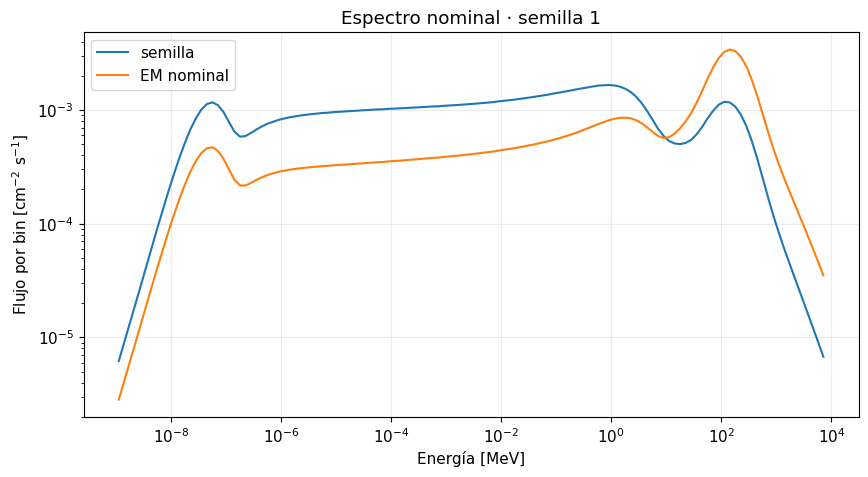

In [15]:
seed_row = SEED_NUMBER - 1
if seed_row >= len(em_table):
    raise IndexError("SEED_NUMBER no está disponible en el ROOT nominal.")

nominal_row = em_table.iloc[seed_row]
final_integral = nominal_spectra[seed_row]
final_differential = final_integral / energy_width
diff_branch = "diff_criteria" if "diff_criteria" in em_table else "diff"

nominal_summary = pd.DataFrame({
    "magnitud": ["Semilla (VWC %)", "Iteración final", "Chi2 final",
                 "Chi2 reducido", "diff final"],
    "valor": [
        nominal_row.get("seed_bin_edgeds", 100 * water_fraction),
        nominal_row["em_it"],
        nominal_row["Chi2"],
        nominal_row["Chi2red"],
        nominal_row[diff_branch],
    ],
})
display(nominal_summary)

fig, axis = plt.subplots()
axis.loglog(energy_mid, seed_integral, label="semilla")
axis.loglog(energy_mid, final_integral, label="EM nominal")
axis.set(xlabel="Energía [MeV]",
         ylabel=r"Flujo por bin [cm$^{-2}$ s$^{-1}$]",
         title=f"Espectro nominal · semilla {SEED_NUMBER}")
axis.legend()
plt.show()


## 8. ¿Por qué se detuvo?

El C++ itera mientras falle al menos una condición:

$
\chi^2>N_{\mathrm{det}}\quad\text{o}\quad\mathrm{diff}>0.02.
$

Por ello, la parada adoptada requiere simultáneamente:

$
\boxed{\chi^2\leq N_{\mathrm{det}}\quad\text{y}\quad\mathrm{diff}\leq0.02}
$

salvo que se alcance antes el máximo. El log oficial conserva ambos diagnósticos para cada iteración.


,iteración,Chi2,diff
0,1,49.79420,0.560012
1,2,23.92530,0.175541
2,3,15.00640,0.089595
3,4,11.48060,0.047877
4,5,9.60054,0.027508
5,6,8.33321,0.017866


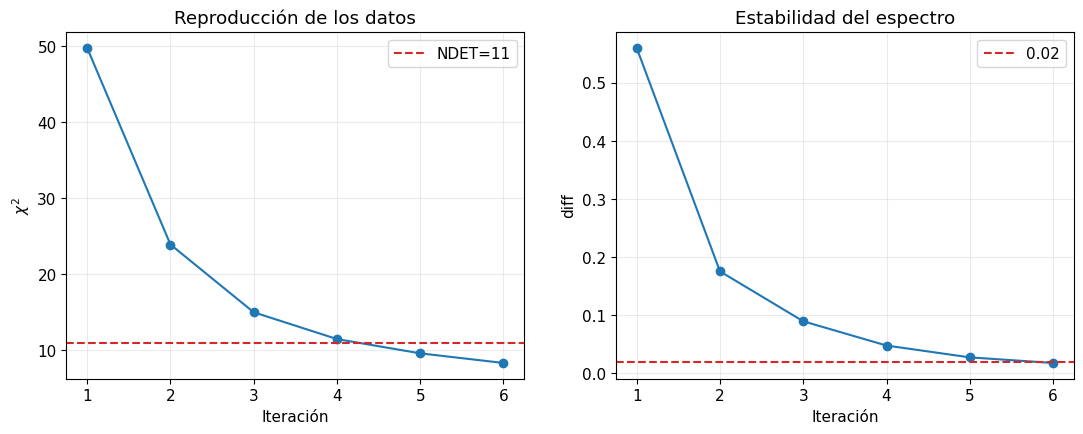

Cumple ambos criterios: True
Iteración final: 6 | máximo configurado: 100


In [16]:
history = em_iteration_history(em_log, SEED_NUMBER)
display(history)

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
left.plot(history["iteración"], history["Chi2"], "o-")
left.axhline(int(config["NDET"]), color="tab:red", linestyle="--",
             label=f"NDET={config['NDET']}")
left.set(xlabel="Iteración", ylabel=r"$\chi^2$",
         title="Reproducción de los datos")
left.legend()

right.plot(history["iteración"], history["diff"], "o-")
right.axhline(0.02, color="tab:red", linestyle="--", label="0.02")
right.set(xlabel="Iteración", ylabel="diff",
          title="Estabilidad del espectro")
right.legend()
plt.show()

last = history.iloc[-1]
criteria_met = (
    last["Chi2"] <= int(config["NDET"]) and last["diff"] <= 0.02
)
print("Cumple ambos criterios:", criteria_met)
print("Iteración final:", int(last["iteración"]),
      "| máximo configurado:", config["MAX_STEPS"])


Más iteraciones no garantizan una solución más física. La parada funciona como regularización:

| Caso | Refolding | Forma esperada | Interpretación |
|---|---|---|---|
| Temprana | Deficiente | Cercana a la semilla | Subajuste |
| Adoptada | Compatible | Estable | Compromiso seleccionado |
| Tardía | Mejora pequeña | Puede volverse irregular | Riesgo de ajustar fluctuaciones |


## 9. Refolding: validar la solución

Volvemos a plegar el espectro nominal:

$
\widehat n_i=\sum_jR_{ij}\phi_j\Delta E_j.
$

Una solución aceptable debe reproducir las tasas dentro de sus incertidumbres, no solamente verse suave.


In [17]:
refolded_rate = forward_fold(
    response_matrix, final_differential, energy_width
)
normalized_residual = (measured_rate - refolded_rate) / measured_sigma
refold_ratio = refolded_rate / measured_rate
refold_chi2 = np.sum(normalized_residual ** 2)

refold_table = event_table[["Canal", "Tasa [s⁻¹]",
                            "Incertidumbre [s⁻¹]"]].copy()
refold_table["Tasa refoldeada [s⁻¹]"] = refolded_rate
refold_table["Residuo normalizado"] = normalized_residual
refold_table["Refold / medida"] = refold_ratio
display(refold_table.style.format({
    "Tasa [s⁻¹]": "{:.5f}",
    "Incertidumbre [s⁻¹]": "{:.5f}",
    "Tasa refoldeada [s⁻¹]": "{:.5f}",
    "Residuo normalizado": "{:.2f}",
    "Refold / medida": "{:.3f}",
}))
print(f"χ² recalculado en Python: {refold_chi2:.5f}")
print(f"χ² guardado por ROOT    : {nominal_row['Chi2']:.5f}")


,Canal,Tasa [s⁻¹],Incertidumbre [s⁻¹],Tasa refoldeada [s⁻¹],Residuo normalizado,Refold / medida
0,D01,0.63667,0.02660,0.61811,0.70,0.971
1,D02,0.67444,0.02737,0.65096,0.86,0.965
2,D03,0.27000,0.01732,0.25533,0.85,0.946
3,D04,0.54889,0.02470,0.59297,-1.79,1.080
4,D05,0.04556,0.00711,0.04077,0.67,0.895
5,D09,0.01111,0.00351,0.00951,0.45,0.856
6,D10,0.59222,0.02565,0.59168,0.02,0.999
7,D11,0.40778,0.02129,0.43567,-1.31,1.068
8,D12,0.06333,0.00839,0.06762,-0.51,1.068
9,D13,0.05444,0.00778,0.05024,0.54,0.923


χ² recalculado en Python: 8.33321
χ² guardado por ROOT    : 8.33321


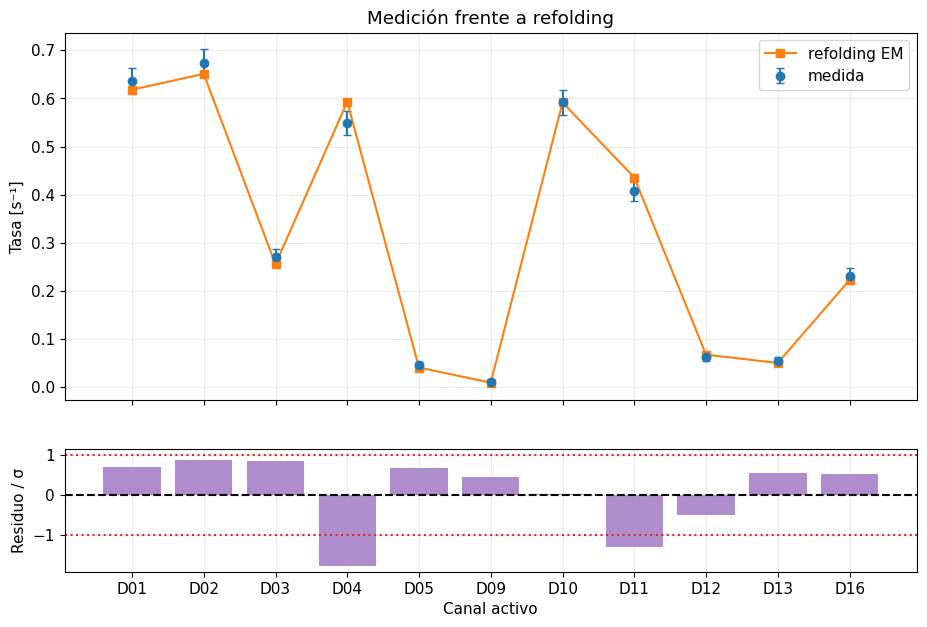

In [18]:
x = np.arange(len(channels))
fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)
top.errorbar(x, measured_rate, yerr=measured_sigma, fmt="o",
             capsize=3, label="medida")
top.plot(x, refolded_rate, "s-", label="refolding EM")
top.set(ylabel="Tasa [s⁻¹]", title="Medición frente a refolding")
top.legend()
bottom.axhline(0, color="black", linestyle="--")
bottom.bar(x, normalized_residual, color="tab:purple", alpha=0.75)
bottom.axhline(1, color="tab:red", linestyle=":")
bottom.axhline(-1, color="tab:red", linestyle=":")
bottom.set(ylabel="Residuo / σ", xlabel="Canal activo",
           xticks=x, xticklabels=channels)
plt.show()


**Pregunta central:** ¿el espectro reconstruido reproduce todos los canales dentro de sus incertidumbres?


## 10. Incertidumbre mediante Monte Carlo

Para cada intento se fluctúan los conteos según el modelo implementado en C++, se ejecuta EM y se aplican criterios de aceptación:

```text
conteos → fluctuación → nuevo conjunto → EM
        → criterios → espectro aceptado o rechazado
```

| Nivel | Pregunta |
|---|---|
| Parada EM | ¿Cuándo dejamos de iterar una realización? |
| Aceptación MC | ¿La realización convergió lo suficiente para integrar la muestra? |

La aceptación exige `em_it < MC_MAX_STEPS`, `Chi2 < NDET` y `diff < DIFF_LIMIT`.

> **Advertencia:** la celda siguiente configura un MC reducido. No utiliza los 10 000 aceptados de producción y no se ejecuta con **Run All** hasta cambiar explícitamente `RUN_REDUCED_MC=True`.


In [37]:
RUN_REDUCED_MC = False
TARGET_ACCEPTED = 1
MAX_MC_TRIALS = 200_000
MC_MAX_STEPS = 20
DIFF_LIMIT = 0.02

if TARGET_ACCEPTED > 5000:
    raise ValueError("TARGET_ACCEPTED debe ser ≤ 500 en modo docente.")

mc_file = expected_mc_output(CONFIG_FILE, EVENT_ID)
mc_stats_file = expected_mc_stats(CONFIG_FILE, EVENT_ID)
mc_command = (
    "bash local_scripts/run_event_em_mc_local.sh "
    f"{CONFIG_FILE} {EVENT_ID} {TARGET_ACCEPTED} "
    f"{MAX_MC_TRIALS} {MC_MAX_STEPS} {DIFF_LIMIT}"
)
print("Comando MC :", mc_command)
print("Salida ROOT:", mc_file)
print("Resumen    :", mc_stats_file)

if RUN_REDUCED_MC:
    if REUSE_EXISTING_RESULTS and mc_file.is_file() and mc_stats_file.is_file():
        print("\nSe reutiliza el MC existente; revisa abajo su estadística real.")
    else:
        try:
            run_em_mc(
                CONFIG_FILE,
                EVENT_ID,
                target_accepted=TARGET_ACCEPTED,
                max_mc_trials=MAX_MC_TRIALS,
                mc_max_steps=MC_MAX_STEPS,
                diff_limit=DIFF_LIMIT,
            )
        except subprocess.CalledProcessError as error:
            print(f"\nEl MC terminó con código {error.returncode}.")
            print("Revisa outputs/log/local_em_mc/.")
            raise
else:
    print("\nMC no iniciado. Cambia RUN_REDUCED_MC=True para ejecutarlo.")

if mc_file.is_file():
    relative_mc_file = mc_file.relative_to(REPO_DIR)
    print("\nROOT disponible para descarga individual:")
    display(FileLink(str(relative_mc_file), url_prefix="/files/"))
    if mc_stats_file.is_file():
        relative_stats_file = mc_stats_file.relative_to(REPO_DIR)
        print("Resumen de la ejecución:")
        display(FileLink(str(relative_stats_file), url_prefix="/files/"))
elif RUN_REDUCED_MC:
    raise FileNotFoundError(
        f"El Monte Carlo terminó sin dejar el ROOT esperado: {mc_file}"
    )


Comando MC : bash local_scripts/run_event_em_mc_local.sh configs/unfolding_configs/config_EM_MC_stop_LCO_15min_ISO.sh 2 1 200000 20 0.02
Salida ROOT: /workspace/outputs/root/deconv_data_rootfile/EM_MC_stop/LCO/LCO_FTFP_BERT_ISO/EM_unfolding_loop_campaign_LCO_event_2_steps_0_timegrid_15_ndet_11_MC_stop.root
Resumen    : /workspace/outputs/root/deconv_data_rootfile/EM_MC_stop/LCO/LCO_FTFP_BERT_ISO/LCO_event_2_15min_stat.txt

MC no iniciado. Cambia RUN_REDUCED_MC=True para ejecutarlo.


### Resultados aceptados y rechazados


In [38]:
if mc_file.is_file():
    print("Árboles:", tree_names(mc_file))
    print("Entradas aceptadas:", tree_entry_count(mc_file))
    display(pd.DataFrame({"Branch": tree_branches(mc_file)}))
    mc_table = scalar_tree_table(mc_file, max_rows=None)
    mc_spectra = vector_tree_array(mc_file)
    mc_stats = mc_run_summary(CONFIG_FILE, EVENT_ID)
    display(pd.DataFrame([mc_stats]))
    print("Forma de los espectros MC:", mc_spectra.shape)
else:
    mc_table = pd.DataFrame()
    mc_spectra = np.empty((0, len(energy_mid)))
    mc_stats = None
    print("No existe un ROOT MC para este evento. Ejecuta la celda protegida.")


Árboles: ['em_loop_tree']
Entradas aceptadas: 1000


,Branch
0,deconv_vec
1,ndet
2,Intg_total
3,Intg_th
4,Intg_ep
5,Intg_fs
6,Intg_he
7,Chi2
8,Chi2red
9,diff


,intentos,aceptadas,rechazadas,meta,fracción
0,1508,1000,508,1000,0.66313


Forma de los espectros MC: (1000, 129)


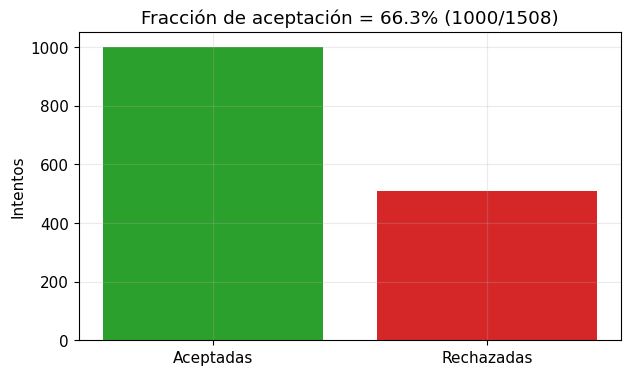

In [39]:
if mc_stats is not None:
    fig, axis = plt.subplots(figsize=(7, 4))
    axis.bar(
        ["Aceptadas", "Rechazadas"],
        [mc_stats["aceptadas"], mc_stats["rechazadas"]],
        color=["tab:green", "tab:red"],
    )
    axis.set(ylabel="Intentos", title=(
        f"Fracción de aceptación = {mc_stats['fracción']:.1%} "
        f"({mc_stats['aceptadas']}/{mc_stats['intentos']})"
    ))
    plt.show()
else:
    print("Sin resumen MC.")


### Diagnósticos de las realizaciones aceptadas


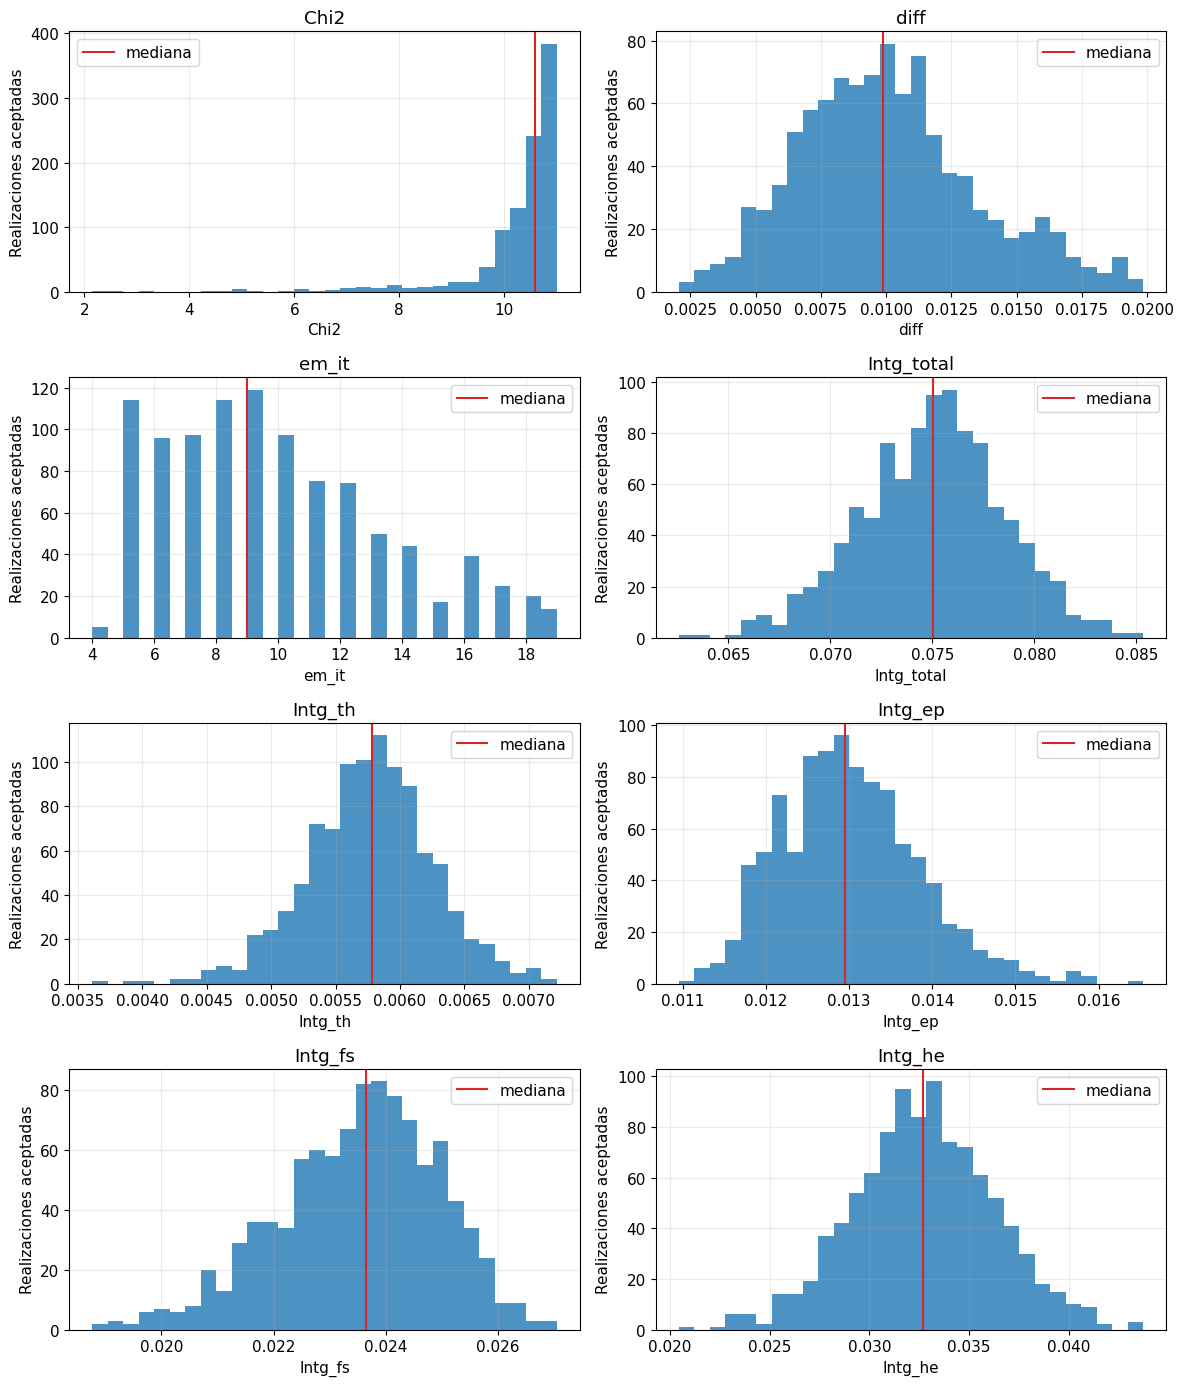

,q15.865,mediana,q84.135,incertidumbre_-,incertidumbre_+,media,desv_std,n
Chi2,9.866871,10.585162,10.889412,0.718290,0.304250,10.240633,1.096003,1000
diff,0.006695,0.009870,0.013549,0.003174,0.003680,0.010101,0.003441,1000
em_it,6.000000,9.000000,13.508650,3.000000,4.508650,9.707000,3.596399,1000
Intg_total,0.071485,0.075040,0.078491,0.003555,0.003451,0.075015,0.003501,1000
Intg_th,0.005306,0.005786,0.006235,0.000480,0.000449,0.005768,0.000487,1000
Intg_ep,0.012132,0.012956,0.013825,0.000824,0.000869,0.013011,0.000840,1000
Intg_fs,0.022032,0.023648,0.024969,0.001616,0.001321,0.023508,0.001434,1000
Intg_he,0.029301,0.032716,0.036266,0.003416,0.003549,0.032728,0.003550,1000


In [36]:
distribution_columns = [
    "Chi2", "diff", "em_it", "Intg_total",
    "Intg_th", "Intg_ep", "Intg_fs", "Intg_he",
]

if not mc_table.empty:
    available = [column for column in distribution_columns
                 if column in mc_table]
    fig, axes = plt.subplots(4, 2, figsize=(12, 14))
    for axis, column in zip(axes.flat, available):
        values = mc_table[column].dropna()
        axis.hist(values, bins=30, color="tab:blue", alpha=0.8)
        axis.axvline(values.median(), color="tab:red",
                     label="mediana")
        axis.set(title=column, xlabel=column,
                 ylabel="Realizaciones aceptadas")
        axis.legend()
    for axis in axes.flat[len(available):]:
        axis.set_visible(False)
    fig.tight_layout()
    plt.show()
    display(quantile_summary(mc_table, available))
else:
    print("Sin realizaciones MC para graficar.")


### Espectros aceptados y banda de incertidumbre

Se muestran como máximo 20 realizaciones. La banda usa \(q_{15.865}\), la mediana y \(q_{84.135}\) en cada bin; no se supone simetría.


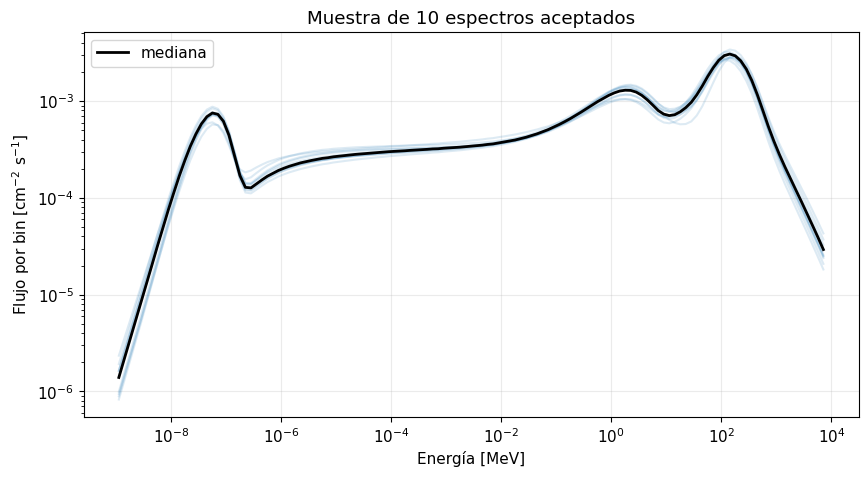

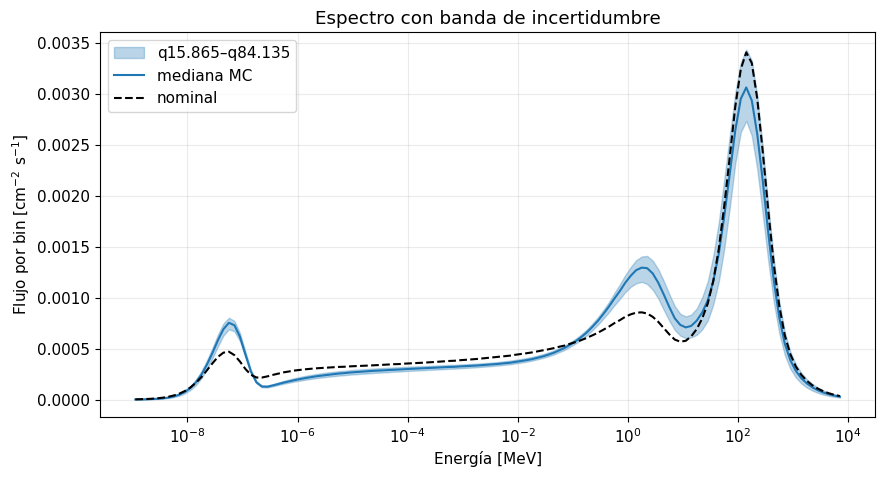

In [33]:
if len(mc_spectra):
    q_low, q_median, q_high = np.quantile(
        mc_spectra, [0.15865, 0.5, 0.84135], axis=0
    )
    sample_count = min(TARGET_ACCEPTED, len(mc_spectra))
    sample_indices = np.linspace(
        0, len(mc_spectra) - 1, sample_count, dtype=int
    )

    fig, axis = plt.subplots()
    for index in sample_indices:
        axis.loglog(energy_mid, mc_spectra[index],
                    color="tab:blue", alpha=0.15)
    axis.loglog(energy_mid, q_median, color="black",
                linewidth=2, label="mediana")
    axis.set(xlabel="Energía [MeV]",
             ylabel=r"Flujo por bin [cm$^{-2}$ s$^{-1}$]",
             title=f"Muestra de {sample_count} espectros aceptados")
    axis.legend()
    plt.show()

    fig, axis = plt.subplots()
    axis.fill_between(energy_mid, q_low, q_high, color="tab:blue",
                      alpha=0.3, label="q15.865–q84.135")
    axis.loglog(energy_mid, q_median, color="tab:blue",
                label="mediana MC")
    axis.loglog(energy_mid, final_integral, color="black",
                linestyle="--", label="nominal")
    axis.set_xscale("log")
    axis.set_yscale("linear")
    axis.set(xlabel="Energía [MeV]",
             ylabel=r"Flujo por bin [cm$^{-2}$ s$^{-1}$]",
             title="Espectro con banda de incertidumbre")
    axis.legend()
    plt.show()
else:
    q_low = q_median = q_high = None
    print("La banda aparecerá después de generar o cargar el MC.")


> **Alcance de la banda:** describe la incertidumbre asociada al modelo de fluctuaciones usado por el Monte Carlo. No incluye automáticamente todas las incertidumbres sistemáticas de respuestas, calibraciones, hipótesis angular, semillas, tiempos vivos, selección de canales o eficiencia.


## 11. Flujos integrales y razón térmica

El C++ integra cada réplica antes de guardar `Intg_th`, `Intg_ep`, `Intg_fs`, `Intg_he` e `Intg_total`. Por ello, los cuantiles siguientes respetan las correlaciones entre bins.

\[
\mathcal R=\frac{\Phi_{\mathrm{th}}}
{\Phi_{\mathrm{ep}}+\Phi_{\mathrm{fast}}}
\]

también se calcula réplica a réplica, no como cociente de medianas.


,Región,Intervalo aproximado [MeV],mediana,incertidumbre_-,incertidumbre_+
0,Térmica,≤ 1.9×10⁻⁷,0.00578557,0.00048,0.000449
1,Epitérmica,2.2×10⁻⁷ – 9×10⁻³,0.0129559,0.000824,0.000869
2,Rápida,1.1×10⁻² – 8.9,0.0236479,0.00162,0.00132
3,Alta energía,10.5 – 7.6×10³,0.0327164,0.00342,0.00355
4,Total,todos,0.07504,0.00356,0.00345


,mediana,incertidumbre_-,incertidumbre_+
Razón térmica,0.15818,0.013358,0.012746


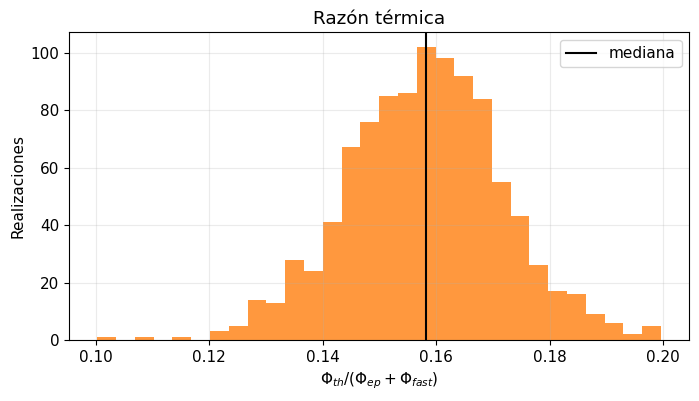

In [24]:
region_info = pd.DataFrame({
    "Región": ["Térmica", "Epitérmica", "Rápida",
               "Alta energía", "Total"],
    "Branch": ["Intg_th", "Intg_ep", "Intg_fs",
               "Intg_he", "Intg_total"],
    "Intervalo aproximado [MeV]": [
        "≤ 1.9×10⁻⁷", "2.2×10⁻⁷ – 9×10⁻³",
        "1.1×10⁻² – 8.9", "10.5 – 7.6×10³", "todos",
    ],
})

if not mc_table.empty:
    integral_quantiles = quantile_summary(
        mc_table, region_info["Branch"]
    ).reset_index(names="Branch")
    integral_table = region_info.merge(
        integral_quantiles, on="Branch", how="left"
    )[[
        "Región", "Intervalo aproximado [MeV]", "mediana",
        "incertidumbre_-", "incertidumbre_+",
    ]]
    display(integral_table.style.format({
        "mediana": "{:.6g}",
        "incertidumbre_-": "{:.3g}",
        "incertidumbre_+": "{:.3g}",
    }))

    thermal_ratio = (
        mc_table["Intg_th"]
        / (mc_table["Intg_ep"] + mc_table["Intg_fs"])
    )
    ratio_quantiles = thermal_ratio.quantile(
        [0.15865, 0.5, 0.84135]
    )
    ratio_summary = {
        "mediana": ratio_quantiles.loc[0.5],
        "incertidumbre_-": (
            ratio_quantiles.loc[0.5] - ratio_quantiles.loc[0.15865]
        ),
        "incertidumbre_+": (
            ratio_quantiles.loc[0.84135] - ratio_quantiles.loc[0.5]
        ),
    }
    display(pd.DataFrame([ratio_summary], index=["Razón térmica"]))

    fig, axis = plt.subplots(figsize=(8, 4))
    axis.hist(thermal_ratio, bins=30, color="tab:orange", alpha=0.8)
    axis.axvline(ratio_summary["mediana"], color="black",
                 label="mediana")
    axis.set(xlabel=r"$\Phi_{th}/(\Phi_{ep}+\Phi_{fast})$",
             ylabel="Realizaciones", title="Razón térmica")
    axis.legend()
    plt.show()
else:
    integral_table = pd.DataFrame()
    thermal_ratio = pd.Series(dtype=float)
    ratio_summary = None
    print("Los flujos y la razón aparecerán después del MC.")


## 12. Comparación opcional con alta estadística

El docente puede colocar un ROOT de referencia en la ruta siguiente. Si no está disponible, el notebook continúa sin error. El archivo debe contener `em_loop_tree/deconv_vec` para el mismo evento y configuración.


In [25]:
REFERENCE_MC_FILE = (
    REPO_DIR / "data/reference"
    / f"{config['CAMPAIGN']}_event_{EVENT_ID}_high_statistics.root"
)

if REFERENCE_MC_FILE.is_file() and len(mc_spectra):
    reference_spectra = vector_tree_array(REFERENCE_MC_FILE)
    ref_low, ref_median, ref_high = np.quantile(
        reference_spectra, [0.15865, 0.5, 0.84135], axis=0
    )
    fig, axis = plt.subplots()
    axis.fill_between(energy_mid, q_low, q_high,
                      color="tab:blue", alpha=0.25,
                      label=f"docente (n={len(mc_spectra)})")
    axis.loglog(energy_mid, q_median, color="tab:blue")
    axis.fill_between(energy_mid, ref_low, ref_high,
                      color="tab:orange", alpha=0.22,
                      label=f"referencia (n={len(reference_spectra)})")
    axis.loglog(energy_mid, ref_median, color="tab:orange")
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set(xlabel="Energía [MeV]",
             ylabel=r"Flujo por bin [cm$^{-2}$ s$^{-1}$]",
             title="MC docente frente a referencia")
    axis.legend()
    plt.show()
else:
    print("Referencia de alta estadística no disponible en:")
    print(REFERENCE_MC_FILE)
    print("La comparación queda preparada para cuando se agregue el ROOT.")


Referencia de alta estadística no disponible en:
/workspace/data/reference/LCO_event_2_high_statistics.root
La comparación queda preparada para cuando se agregue el ROOT.


## 13. Resumen automático del evento


In [26]:
if not integral_table.empty:
    integral_values = integral_table.set_index("Región")["mediana"]
else:
    integral_values = pd.Series(dtype=float)

summary_rows = {
    "Campaña": config["CAMPAIGN"],
    "Evento": EVENT_ID,
    "Número de detectores": config["NDET"],
    "Tiempo de integración [min]": config["TIME_GRID"],
    "Semilla": SEED_NUMBER,
    "VWC semilla [%]": 100 * water_fraction,
    "Iteración de parada": int(nominal_row["em_it"]),
    "Chi2 final": float(nominal_row["Chi2"]),
    "diff final": float(nominal_row[diff_branch]),
    "Intentos MC": mc_stats["intentos"] if mc_stats else "no ejecutado",
    "Realizaciones aceptadas": (
        mc_stats["aceptadas"] if mc_stats else "no ejecutado"
    ),
    "Fracción de aceptación": (
        mc_stats["fracción"] if mc_stats else np.nan
    ),
    "Flujo térmico": integral_values.get("Térmica", np.nan),
    "Flujo epitérmico": integral_values.get("Epitérmica", np.nan),
    "Flujo rápido": integral_values.get("Rápida", np.nan),
    "Flujo de alta energía": integral_values.get("Alta energía", np.nan),
    "Flujo total": integral_values.get("Total", np.nan),
    "Razón térmica": (
        ratio_summary["mediana"] if ratio_summary else np.nan
    ),
}
display(pd.DataFrame(
    {"Magnitud": summary_rows.keys(), "Valor": summary_rows.values()}
))


,Magnitud,Valor
0,Campaña,LCO
1,Evento,2
2,Número de detectores,11
3,Tiempo de integración [min],15
4,Semilla,1
5,VWC semilla [%],0.0
6,Iteración de parada,6
7,Chi2 final,8.333209
8,diff final,0.017866
9,Intentos MC,1508


## 14. Descargar los cinco eventos, uno por uno

Repite el flujo anterior para cada `EVENT_ID` asignado. Esta sección **no ejecuta cálculos ni mueve archivos**: comprueba los cinco ROOT y muestra un enlace separado para cada uno. Descárgalos manualmente y súbelos al repositorio indicado por el docente.

Codespaces guarda los archivos dentro del repositorio montado en `/workspace`. La ruta correcta es `/workspace/outputs/root/deconv_data_rootfile/EM_MC_stop/`: `deconv_data_rootfile` va en singular y `EM_MC_stop` no lleva `_` inicial. El ROOT aparece cuando termina el Monte Carlo, no mientras continúa ejecutándose.


In [ ]:
# Escribe aquí exactamente los cinco eventos indicados por el docente.
ASSIGNED_EVENT_IDS = [1, 2, 3, 4, 5]

if len(ASSIGNED_EVENT_IDS) != 5 or len(set(ASSIGNED_EVENT_IDS)) != 5:
    raise ValueError("Debes indicar exactamente cinco eventos diferentes.")

missing_events = []
for assigned_event in ASSIGNED_EVENT_IDS:
    result_file = expected_mc_output(CONFIG_FILE, assigned_event)
    if result_file.is_file():
        relative_result = result_file.relative_to(REPO_DIR)
        size_mb = result_file.stat().st_size / (1024 ** 2)
        print(f"Evento {assigned_event}: {size_mb:.2f} MiB")
        display(FileLink(str(relative_result), url_prefix="/files/"))
    else:
        missing_events.append(assigned_event)
        print(f"Evento {assigned_event}: falta ejecutar el Monte Carlo.")

if missing_events:
    print("\nFaltan eventos:", missing_events)
else:
    print("\nLos cinco ROOT están listos para descargar uno por uno.")


## Cierre

**Pregunta final:** ¿la solución reproduce adecuadamente las tasas medidas y qué región del espectro presenta mayor incertidumbre?

La idea principal es que el espectro no se mide directamente; se infiere y se valida mediante:

\[
\boxed{\text{datos}+R+\text{algoritmo}+\text{parada}
+\text{propagación de incertidumbre}}
\]

Para comparar una segunda condición física, conviene **cargar un segundo evento precalculado** y contrastar sus flujos integrales o su razón térmica, sin iniciar otra ejecución extensa durante la clase.
